# LSTM autoencoder

Two things change here:

- a longer window: 2 seconds around the R peak instead of 0.65 s, long enough to hold the previous beat and the next one. A beat that comes early now shows up inside the  window itself, as a neighbour that sits closer than usual.
- an LSTM instead of convolutions: it walks along the window one time step after the other and carries a memory of what it has already seen, so it can relate the end of the window to its beginning. A convolution only ever looks through a small sliding filter.

In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch

from m1_defect_anomaly_2026.beats import load_split
from m1_defect_anomaly_2026.splits import DS1_train, DS2_test
from m1_defect_anomaly_2026.preprocessing import FS
from m1_defect_anomaly_2026.unsupervised import subsample
from m1_defect_anomaly_2026.evaluation import (evaluate_scores, select_threshold,
                                               build_table, save_table)
from m1_defect_anomaly_2026.autoencoders import (LstmAutoencoder, long_beat_windows,
                                                 long_window_starts, split_records,
                                                 stack_windows, train_autoencoder,
                                                 reconstruct, squared_error,
                                                 reconstruction_error, percentile_threshold,
                                                 threshold_sweep, error_curve, set_seed,
                                                 LONG_SECONDS, DECIMATE)

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA = str(REPO_ROOT / "data" / "raw")
RESULTS_DIR = Path("../results/autoencoders")
FIG_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
set_seed(SEED)
print("torch", torch.__version__, "| threads:", torch.get_num_threads())

torch 2.13.0+cpu | threads: 1


## 1 - The long window

2 seconds at 360 Hz is 720 samples, and an LSTM has to walk through them one by one, which is slow. The bandpass filter of `preprocessing.py` only keeps what is below 10 Hz, so anything above 20 Hz in the signal is already gone: keeping 1 sample out of 6 (60 Hz) throws away nothing real and makes the sequence 6 times shorter.

720 samples -> 120 time steps.

In [7]:
ds1 = load_split(DS1_train, DATA)
ds2 = load_split(DS2_test, DATA)

print(f"DS1: {len(ds1)} records, {sum(r.n_beats for r in ds1):,} beats")
print(f"DS2: {len(ds2)} records, {sum(r.n_beats for r in ds2):,} beats")
print(f"\nwindow: {LONG_SECONDS} s, one sample kept out of {DECIMATE}"
      f" -> {int(LONG_SECONDS * FS / DECIMATE)} time steps at {FS // DECIMATE} Hz")

DS1: 22 records, 51,003 beats
DS2: 22 records, 49,692 beats

window: 2.0 s, one sample kept out of 6 -> 120 time steps at 60 Hz


In [8]:
# the same 5 records are held out as in notebook 05 (same seed), so the two autoencoders
# are trained and thresholded on exactly the same patients
train_records, val_records = split_records(ds1, n_val=5, seed=SEED)
print("validation records:", [r.name for r in val_records])

X_train, meta_train = stack_windows(train_records, long_beat_windows, normal_only=True)
X_val, meta_val = stack_windows(val_records, long_beat_windows, normal_only=True)
X_val_all, meta_val_all = stack_windows(val_records, long_beat_windows, normal_only=False)
X_test, meta_test = stack_windows(ds2, long_beat_windows, normal_only=False)
y_test = meta_test["y"].to_numpy()

print()
print("train windows (normal only):", X_train.shape)
print("val windows   (normal only):", X_val.shape)
print("test windows  (all of DS2) :", X_test.shape,
      "- anomaly rate", round(float(y_test.mean()), 3))

validation records: ['122', '201', '208', '209', '230']

train windows (normal only): (35280, 120)
val windows   (normal only): (10569, 120)
test windows  (all of DS2) : (49692, 120) - anomaly rate 0.11


## 2 - The model

The encoder LSTM reads the 120 time steps and keeps one memory state at the end. That
state is squeezed into **8 numbers**, then repeated 120 times and handed to a second LSTM
which unrolls the window again.

The bottleneck is smaller than in notebook 05 (8 instead of 16) because the window is
smoother after decimation, and a bottleneck that is too wide would let the model copy its
input instead of learning what a normal rhythm looks like.

In [9]:
set_seed(SEED)
model = LstmAutoencoder(hidden_size=64, latent_dim=16)
print(model)
print()
print("time steps per window:", X_train.shape[1])
print("bottleneck           :", model.latent_dim, "numbers per beat")
print("parameters           :", f"{sum(p.numel() for p in model.parameters()):,}")

LstmAutoencoder(
  (encoder): LSTM(1, 64, batch_first=True)
  (to_latent): Linear(in_features=64, out_features=16, bias=True)
  (from_latent): Linear(in_features=16, out_features=64, bias=True)
  (decoder): LSTM(64, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

time steps per window: 120
bottleneck           : 16 numbers per beat
parameters           : 52,625


An LSTM on CPU is much slower than a convolution: it cannot process the 120 time steps in
parallel. Training on a sample of the windows keeps the run reasonable - raise
`MAX_TRAIN_WINDOWS` if you have the time, the normal beats are very repetitive so the
sample is representative.

In [ ]:
MAX_TRAIN_WINDOWS = 20_000   # raise to None to train on all of them

X_train_used = subsample(X_train, MAX_TRAIN_WINDOWS, seed=SEED)
print("training on", len(X_train_used), "windows out of", len(X_train))

start = time.time()
history = train_autoencoder(model, X_train_used, X_val,
                            epochs=40, batch_size=256, lr=3e-3,
                            patience=10, seed=SEED, verbose=True)
print(f"\ntraining took {(time.time() - start) / 60:.1f} min")

training on 20000 windows out of 35280
epoch   1/40  train 0.98098  val 0.99131
epoch   2/40  train 0.97430  val 1.02458
epoch   3/40  train 0.97766  val 0.99147
epoch   4/40  train 0.97038  val 0.99122
epoch   5/40  train 0.97736  val 0.99089
epoch   6/40  train 0.96799  val 0.98920
epoch   7/40  train 0.96467  val 1.00685
epoch   8/40  train 0.95830  val 0.99027
epoch   9/40  train 0.95958  val 0.99270
epoch  10/40  train 0.94075  val 0.99956
epoch  11/40  train 0.93227  val 0.97731
epoch  12/40  train 0.90090  val 0.94843
epoch  13/40  train 0.85600  val 0.95322
epoch  14/40  train 0.86638  val 0.98752
epoch  15/40  train 1.00635  val 0.99258
epoch  16/40  train 0.98156  val 0.99061
epoch  17/40  train 0.98216  val 0.99218
epoch  18/40  train 0.98050  val 0.99109
epoch  19/40  train 0.97965  val 0.98982


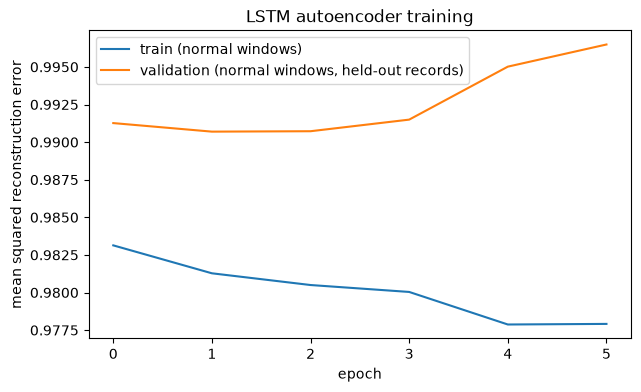

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history["train"], label="train (normal windows)")
plt.plot(history["val"], label="validation (normal windows, held-out records)")
plt.xlabel("epoch")
plt.ylabel("mean squared reconstruction error")
plt.title("LSTM autoencoder training")
plt.legend()
plt.savefig(FIG_DIR / "lstm_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 - What the model rebuilds

The same picture as in notebook 05, but now a whole 2 second stretch is being rebuilt, so
the reconstruction shows where the model expected the neighbouring beats to be.

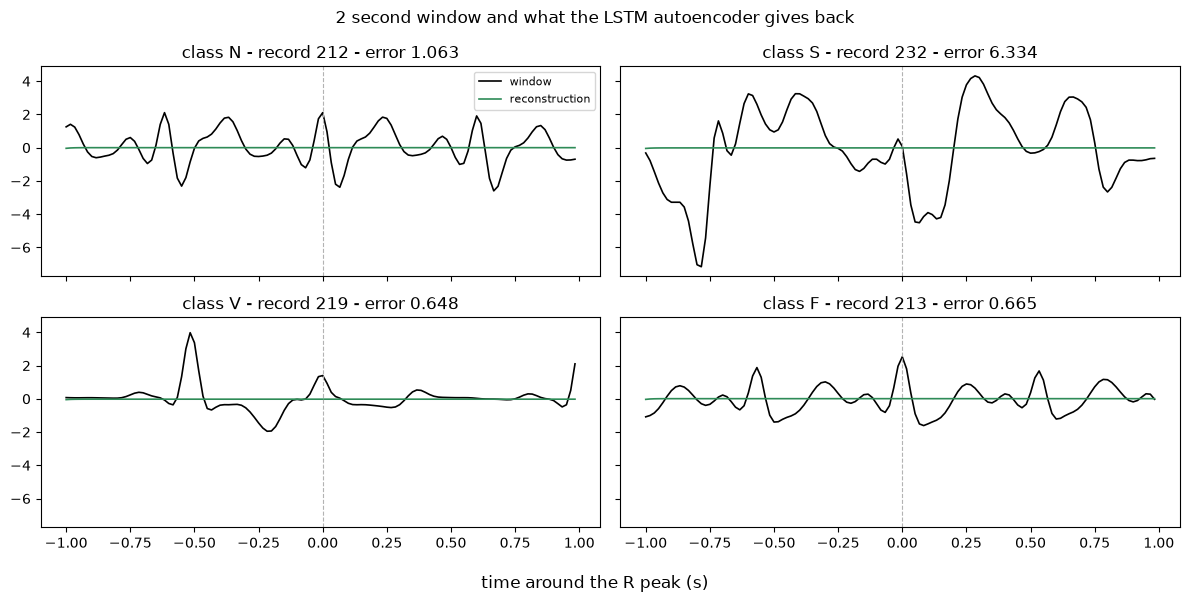

In [8]:
labels_test = meta_test["label"].to_numpy()
t_window = np.arange(X_test.shape[1]) * DECIMATE / FS - LONG_SECONDS / 2

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)
for ax, cls in zip(axes.ravel(), ["N", "S", "V", "F"]):
    rows = np.flatnonzero(labels_test == cls)
    if len(rows) == 0:
        ax.set_visible(False)
        continue
    i = rows[len(rows) // 2]
    original = X_test[i]
    rebuilt = reconstruct(model, X_test[i:i + 1])[0]
    error = float(((original - rebuilt) ** 2).mean())

    ax.plot(t_window, original, color="black", lw=1.2, label="window")
    ax.plot(t_window, rebuilt, color="seagreen", lw=1.2, label="reconstruction")
    ax.axvline(0, color="0.7", ls="--", lw=0.8)
    ax.set_title(f"class {cls} - record {meta_test['record'].iloc[i]} - error {error:.3f}")

axes[0, 0].legend(loc="upper right", fontsize=8)
fig.supxlabel("time around the R peak (s)")
fig.suptitle("2 second window and what the LSTM autoencoder gives back")
fig.tight_layout()
fig.savefig(FIG_DIR / "lstm_reconstructions.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 - Threshold and score

Exactly the same rule as in notebook 05, so the two models can be compared honestly:
a percentile of the reconstruction error of the normal beats of the held-out records.

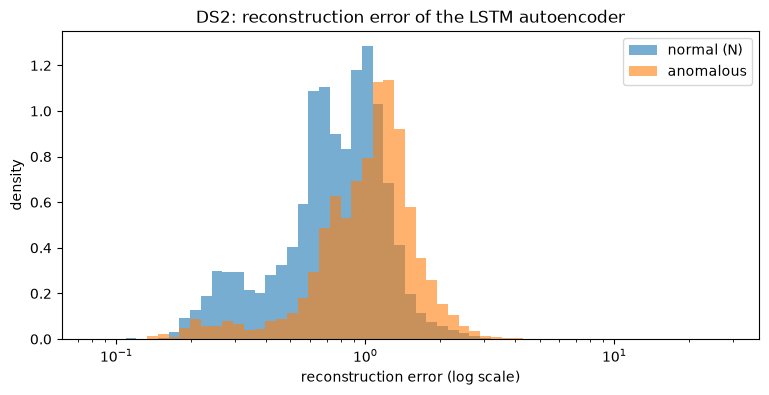

In [9]:
val_scores = reconstruction_error(model, X_val)
test_scores = reconstruction_error(model, X_test)

plt.figure(figsize=(9, 4))
low = max(float(test_scores.min()), 1e-4)
bins = np.logspace(np.log10(low), np.log10(float(test_scores.max())), 60)
plt.hist(test_scores[y_test == 0], bins=bins, alpha=0.6, density=True, label="normal (N)")
plt.hist(test_scores[y_test == 1], bins=bins, alpha=0.6, density=True, label="anomalous")
plt.xscale("log")
plt.xlabel("reconstruction error (log scale)")
plt.ylabel("density")
plt.title("DS2: reconstruction error of the LSTM autoencoder")
plt.legend()
plt.savefig(FIG_DIR / "lstm_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
sweep = threshold_sweep(val_scores, y_test, test_scores,
                        percentiles=(90.0, 95.0, 97.5, 99.0, 99.5))
sweep.round(4)

,percentile,threshold,precision,recall,f1,fp,fn
0,90.0,1.3274,0.2511,0.3881,0.3049,6312,3336
1,95.0,1.5244,0.2638,0.2348,0.2484,3573,4172
2,97.5,1.7667,0.2549,0.1368,0.1781,2181,4706
3,99.0,2.0836,0.2339,0.0688,0.1063,1228,5077
4,99.5,2.2917,0.2267,0.0429,0.0722,798,5218


In [11]:
# keep the same percentile as notebook 05 unless the table above says otherwise
PERCENTILE = 99.0

threshold = percentile_threshold(val_scores, PERCENTILE)
lstm_result = evaluate_scores(y_test, test_scores, threshold, "LSTM autoencoder")

print(f"threshold = {threshold:.4f}  (percentile {PERCENTILE} of the normal validation errors)")
print("precision:", round(lstm_result["precision"], 3))
print("recall   :", round(lstm_result["recall"], 3))
print("F1       :", round(lstm_result["f1"], 3))
print("ROC-AUC  :", round(lstm_result["roc_auc"], 3))

threshold = 2.0836  (percentile 99.0 of the normal validation errors)
precision: 0.234
recall   : 0.069
F1       : 0.106
ROC-AUC  : 0.703


In [12]:
# the labelled rule again, only to measure what the label-free percentile costs
y_val_all = meta_val_all["y"].to_numpy()
val_all_scores = reconstruction_error(model, X_val_all)
f1_threshold, f1_val = select_threshold(y_val_all, val_all_scores)
f1_result = evaluate_scores(y_test, test_scores, f1_threshold, "LSTM autoencoder (best-F1 threshold)")

print(f"percentile {PERCENTILE} -> F1 on DS2 {lstm_result['f1']:.3f}")
print(f"best F1 on validation -> F1 on DS2 {f1_result['f1']:.3f}")

percentile 99.0 -> F1 on DS2 0.106
best F1 on validation -> F1 on DS2 0.316


## 5 - The question this notebook was built to answer

The S beats. The convolutional autoencoder could not see them because its window held no
rhythm. The whole point of the longer window is to give the model that rhythm, so the
comparison below is the real result of this notebook - much more than the overall F1.

In [13]:
meta_test = meta_test.copy()
meta_test["score"] = test_scores
meta_test["flag"] = (test_scores >= threshold).astype(int)

cnn = pd.read_parquet(RESULTS_DIR / "cnn_ae_scores_ds2.parquet")
assert len(cnn) == len(meta_test), "the two notebooks must score the same DS2 beats"
meta_test["cnn_score"] = cnn["score"].to_numpy()
meta_test["cnn_flag"] = cnn["flag"].to_numpy()

anomalies = meta_test[meta_test["y"] == 1]
per_class = anomalies.groupby("label").agg(n_beats=("y", "size"),
                                           caught_by_cnn=("cnn_flag", "mean"),
                                           caught_by_lstm=("flag", "mean"))
print(per_class.round(3).to_string())

       n_beats  caught_by_cnn  caught_by_lstm
label                                        
F          388          0.005           0.005
Q            7          0.714           0.714
S         1837          0.061           0.026
V         3220          0.112           0.100


In [14]:
# are the two autoencoders making the same mistakes?
both = int(((meta_test.cnn_flag == 1) & (meta_test.flag == 1)).sum())
only_cnn = int(((meta_test.cnn_flag == 1) & (meta_test.flag == 0)).sum())
only_lstm = int(((meta_test.cnn_flag == 0) & (meta_test.flag == 1)).sum())

print("flagged by both        :", both)
print("only by the CNN        :", only_cnn)
print("only by the LSTM       :", only_lstm)
print()
print("correlation of the two scores:",
      round(float(np.corrcoef(meta_test.score, meta_test.cnn_score)[0, 1]), 3))

caught_by_either = ((meta_test.cnn_flag == 1) | (meta_test.flag == 1)) & (meta_test.y == 1)
print("recall if we flagged a beat as soon as one of the two models did:",
      round(float(caught_by_either.sum() / (meta_test.y == 1).sum()), 3))

flagged by both        : 376
only by the CNN        : 1234
only by the LSTM       : 1227

correlation of the two scores: 0.431
recall if we flagged a beat as soon as one of the two models did: 0.136


## 6 - On the raw signal

Same picture as in notebook 05, on the same record, so the two error curves can be put
side by side. The only difference is `step=DECIMATE`: one time step of the window covers 6
samples of the recording, and `error_curve()` spreads the error back over all six.

In [15]:
rec = max(ds2, key=lambda r: int(r.y.sum()))
print("record", rec.name, "-", int(rec.y.sum()), "abnormal beats out of", rec.n_beats)

X_rec = long_beat_windows(rec)
starts = long_window_starts(rec)
errors = squared_error(model, X_rec)

err_curve = error_curve(len(rec.signal), starts, errors, step=DECIMATE)
beat_scores = errors.mean(axis=1)
flagged = beat_scores >= threshold

record 232 - 1382 abnormal beats out of 1780


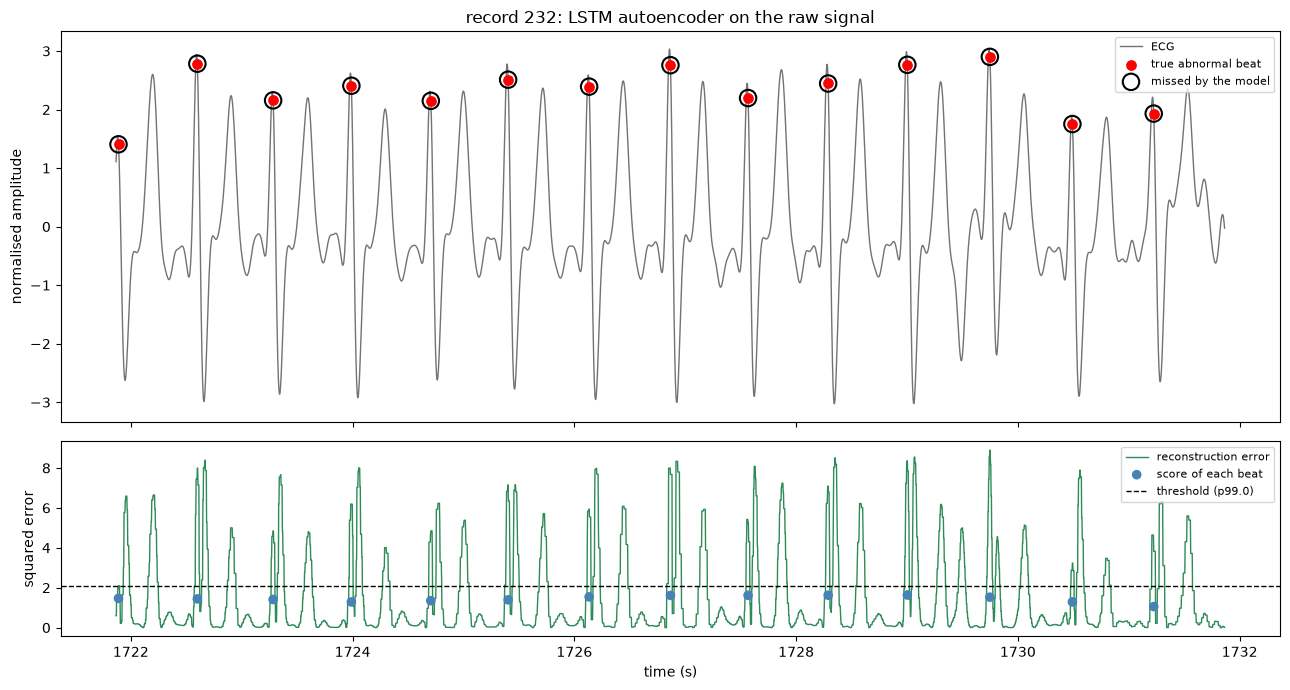

In [16]:
span = 10 * FS
best_start, best_count = 0, -1
for peak in rec.r_peaks[rec.y == 1]:
    low = max(0, int(peak) - span // 2)
    count = int(((rec.r_peaks >= low) & (rec.r_peaks < low + span) & (rec.y == 1)).sum())
    if count > best_count:
        best_count, best_start = count, low

low, high = best_start, best_start + span
t = np.arange(low, high) / FS
inside = (rec.r_peaks >= low) & (rec.r_peaks < high)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(t, rec.signal[low:high], color="0.45", lw=1.0, label="ECG")
true_peaks = rec.r_peaks[inside & (rec.y == 1)]
ax1.scatter(true_peaks / FS, rec.signal[true_peaks], color="red", s=45, zorder=5,
            label="true abnormal beat")
missed = rec.r_peaks[inside & (rec.y == 1) & ~flagged]
ax1.scatter(missed / FS, rec.signal[missed], facecolors="none", edgecolors="black",
            s=140, lw=1.5, zorder=6, label="missed by the model")
ax1.set_ylabel("normalised amplitude")
ax1.set_title(f"record {rec.name}: LSTM autoencoder on the raw signal")
ax1.legend(loc="upper right", fontsize=8)

ax2.plot(t, err_curve[low:high], color="seagreen", lw=1.0, label="reconstruction error")
ax2.scatter(rec.r_peaks[inside] / FS, beat_scores[inside],
            c=np.where(flagged[inside], "crimson", "steelblue"), s=35, zorder=5,
            label="score of each beat")
ax2.axhline(threshold, color="black", ls="--", lw=1, label=f"threshold (p{PERCENTILE})")
ax2.set_xlabel("time (s)")
ax2.set_ylabel("squared error")
ax2.legend(loc="upper right", fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "lstm_signal_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 - The full comparison

Every method built during the internship, measured the same way: threshold chosen on
DS1, score measured on DS2, no patient on both sides.

In [17]:
previous = pd.read_csv(RESULTS_DIR / "comparison_table.csv")
table = build_table(previous.to_dict("records") + [lstm_result])
save_table(table, RESULTS_DIR / "comparison_table.csv", RESULTS_DIR / "comparison_table.md")
table[["method", "precision", "recall", "f1", "roc_auc"]].round(3)

,method,precision,recall,f1,roc_auc
0,Random Forest,0.837,0.633,0.721,0.948
1,XGBoost,0.686,0.677,0.681,0.940
2,Isolation Forest,0.343,0.566,0.427,0.836
3,Spectral features,0.297,0.502,0.373,0.773
4,CUSUM (k=0.5),0.410,0.335,0.369,0.680
5,Z-score (10s window),0.652,0.175,0.276,0.615
6,One-Class SVM,0.200,0.437,0.275,0.687
7,Random baseline,0.110,0.996,0.198,0.500
8,Z-score (1s window),0.110,0.997,0.198,0.274
9,1D CNN autoencoder,0.299,0.088,0.136,0.816


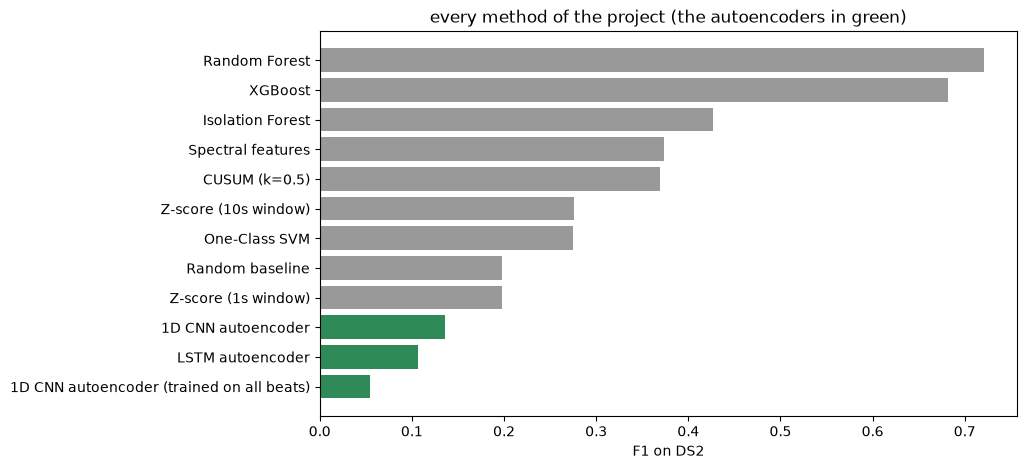

In [18]:
plt.figure(figsize=(9, 5))
ordered = table.sort_values("f1")
colors = ["seagreen" if "autoencoder" in m else "0.6" for m in ordered["method"]]
plt.barh(ordered["method"], ordered["f1"], color=colors)
plt.xlabel("F1 on DS2")
plt.title("every method of the project (the autoencoders in green)")
plt.savefig(FIG_DIR / "all_methods.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
meta_test.to_parquet(RESULTS_DIR / "lstm_ae_scores_ds2.parquet", index=False)
torch.save(model.state_dict(), RESULTS_DIR / "lstm_autoencoder.pt")
print("saved to", RESULTS_DIR.resolve())

saved to /workspaces/2026-m1-internship-defect-detection/results/autoencoders
